In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:
input_file = 'india_monthly_exports_with_indicators.xlsx'
df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value = ('Export_Value', 'sum'),
                  GDP_Growth = ('gdp_growth', 'first'),
                  Inflation_Rate = ('Inflation_rate', 'first'),
                  REER = ('REER', 'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

In [2]:
tf.random.set_seed(42)
np.random.seed(42)
LOOKBACK = 12
N_TEST   = 12

# Feature engineering

In [5]:
monthly['Export_Lag1']  = monthly['Export_Value'].shift(1)
monthly['Export_Lag3']  = monthly['Export_Value'].shift(3)
monthly['Export_Lag12'] = monthly['Export_Value'].shift(12)
monthly['month_sin']    = np.sin(2 * np.pi * monthly.index.month / 12)
monthly['month_cos']    = np.cos(2 * np.pi * monthly.index.month / 12)
monthly = monthly.dropna()

In [6]:
features = [
'Export_Value',
'Export_Lag1',
'Export_Lag3',
'Export_Lag12',
'GDP_Growth',
'Inflation_Rate',
'REER',
'month_sin',
'month_cos'
]

data_raw = monthly[features].values.astype(np.float32)

# TRAIN TEST SPLIT
N = len(data_raw)
train_raw = data_raw[:N-N_TEST]
test_raw  = data_raw[N-N_TEST:]


In [8]:
# Minmax Scaling
scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

def inverse_export(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(features)))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]

In [9]:
# building Sequence
def make_sequences(data, lookback, horizon):
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i - lookback:i, :])
        y.append(data[i:i + horizon, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train_scaled, LOOKBACK, N_TEST)
print(f"Training sequences : {len(X_train)}")
print(f"X shape            : {X_train.shape}")
print(f"y shape            : {y_train.shape}")


Training sequences : 49
X shape            : (49, 12, 9)
y shape            : (49, 12)


In [14]:
def build_lstm(units_1=32, units_2=16, dropout=0.2, lr=1e-3):
    inp = Input(shape=(LOOKBACK, len(features)))
    # First LSTM
    x = LSTM(units_1, return_sequences=True,
             activation='tanh',
             recurrent_activation='sigmoid')(inp)
    x = Dropout(dropout)(x)

    # Second LSTM
    x = LSTM(units_2, return_sequences=False,
             activation='tanh',
             recurrent_activation='sigmoid')(x)
    x = Dropout(dropout)(x)

    # Dense layers — ReLU activation
    x   = Dense(12, activation='relu')(x)
    out = Dense(N_TEST, activation='linear')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

In [15]:

epoch_opts = [200, 300, 500]
batch_opts = [4, 8, 16]

best_val   = np.inf
best_cfg   = (300, 8)
results    = []


In [16]:
for ep in epoch_opts:
    for bs in batch_opts:
        tf.random.set_seed(42)
        m = build_lstm()
        early = EarlyStopping(
            monitor='val_loss',
            patience=30,
            restore_best_weights=True
        )
        h = m.fit(
            X_train, y_train,
            epochs=ep,
            batch_size=bs,
            validation_split=0.1,
            shuffle=False,
            callbacks=[early],
            verbose=0
        )
        vl = min(h.history['val_loss'])
        tl = h.history['loss'][-1]
        results.append({'epochs':ep,'batch':bs,'val_loss':vl,'train_loss':tl})
        mark = ' ◄ best' if vl < best_val else ''
        print(f"{ep:>8} {bs:>6} {vl:>12.6f} {tl:>12.6f}{mark}")
        if vl < best_val:
            best_val = vl
            best_cfg = (ep, bs)

best_ep, best_bs = best_cfg
print(f"\nBest config: epochs={best_ep}, batch={best_bs}, val_loss={best_val:.6f}")

     200      4     0.011789     0.014146 ◄ best
     200      8     0.011657     0.017810 ◄ best
     200     16     0.009253     0.025205 ◄ best
     300      4     0.012123     0.016011
     300      8     0.011676     0.017645
     300     16     0.014669     0.026728
     500      4     0.011281     0.015894
     500      8     0.012532     0.014760
     500     16     0.020770     0.022777

Best config: epochs=200, batch=16, val_loss=0.009253


In [17]:
tf.random.set_seed(42)
final_model = build_lstm(units_1=32, units_2=16, lr=1e-3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15,
                      min_lr=1e-5, verbose=1)
]

print(f"\nFinal training: epochs={best_ep}, batch={best_bs}")
history = final_model.fit(
    X_train, y_train,
    epochs=best_ep,
    batch_size=best_bs,
    validation_split=0.1,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

final_model.summary()
print(f"\nTotal parameters : {final_model.count_params()}")
print(f"Training sequences : {len(X_train)}")
print(f"Param/seq ratio : {final_model.count_params()/len(X_train):.1f}")


Final training: epochs=200, batch=16
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - loss: 0.5263 - mae: 0.6974 - val_loss: 0.5802 - val_mae: 0.7521 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.4768 - mae: 0.6637 - val_loss: 0.5274 - val_mae: 0.7167 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.4380 - mae: 0.6358 - val_loss: 0.4790 - val_mae: 0.6817 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.3948 - mae: 0.6003 - val_loss: 0.4268 - val_mae: 0.6400 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.3586 - mae: 0.5614 - val_loss: 0.3700 - val_mae: 0.5893 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.3145 - mae: 0.5110 - val_loss: 0.3130 - val_mae: 0.5301 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2780 - mae: 0.4613 - val_loss: 0.2612 - val_mae: 0.4665 - lea

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 12, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 12, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 12)             │           156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,618 (103.98 KB)

 Trainable params: 8,872 (34.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,746 (69.32 KB)


Total parameters : 8872
Training sequences : 49
Param/seq ratio : 181.1


In [20]:
#  OOS prediction
last_window = train_scaled[-LOOKBACK:].reshape(1, LOOKBACK, len(features))
pred_scaled = final_model.predict(last_window).flatten()

y_pred = inverse_export(pred_scaled)
y_true = inverse_export(test_scaled[:, 0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


# OOS ACCURACY MATRIX

In [23]:

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
bias = np.mean(y_true - y_pred)


print(f"  RMSE : ${rmse:>10,.2f}M")
print(f"  MAE  : ${mae:>10,.2f}M")
print(f"  MAPE : {mape:>10.2f}%")



  RMSE : $  3,622.90M
  MAE  : $  2,494.74M
  MAPE :       6.45%


# Model Validation

In [24]:
test_index = monthly.index[-N_TEST:]
print(f"\n  {'Month':<12} {'Actual':>12} {'Predicted':>12} {'Error%':>8}")
print(f"  {'─'*48}")
for i, p in enumerate(test_index):
    ep_pct = (y_true[i] - y_pred[i]) / y_true[i] * 100
    print(f"  {str(p):<12} {y_true[i]:>12.2f} {y_pred[i]:>12.2f} {ep_pct:>7.2f}%")


  Month              Actual    Predicted   Error%
  ────────────────────────────────────────────────
  2025-01          36338.46     32376.80   10.90%
  2025-02          36910.95     36977.22   -0.18%
  2025-03          42047.58     33301.21   20.80%
  2025-04          38283.21     31997.85   16.42%
  2025-05          38303.31     36780.91    3.97%
  2025-06          34969.76     34955.89    0.04%
  2025-07          37017.55     35963.18    2.85%
  2025-08          34770.55     36251.36   -4.26%
  2025-09          36132.77     36331.74   -0.55%
  2025-10          34105.71     34378.43   -0.80%
  2025-11          37908.48     34692.96    8.48%
  2025-12          38468.38     35349.83    8.11%


# Forecast

In [26]:
full_scaled    = scaler.transform(data_raw)
future_window  = full_scaled[-LOOKBACK:].reshape(1, LOOKBACK, len(features))
future_scaled  = final_model.predict(future_window).flatten()
future_preds   = inverse_export(future_scaled)
future_index   = pd.period_range(
    start=monthly.index[-1] + 1, periods=12, freq='M')

print(f"\nFuture Forecast (Jan–Dec 2026):")
print(f"  {'Month':<12} {'Forecast (USD M)':>18}")

for p, val in zip(future_index, future_preds):
    print(f"  {str(p):<12} {val:>18,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Future Forecast (Jan–Dec 2026):
  Month          Forecast (USD M)
  2026-01               31,127.46
  2026-02               35,271.30
  2026-03               32,222.97
  2026-04               31,419.42
  2026-05               36,179.51
  2026-06               33,465.83
  2026-07               34,170.34
  2026-08               34,055.51
  2026-09               34,521.17
  2026-10               33,962.57
  2026-11               33,367.90
  2026-12               34,023.08


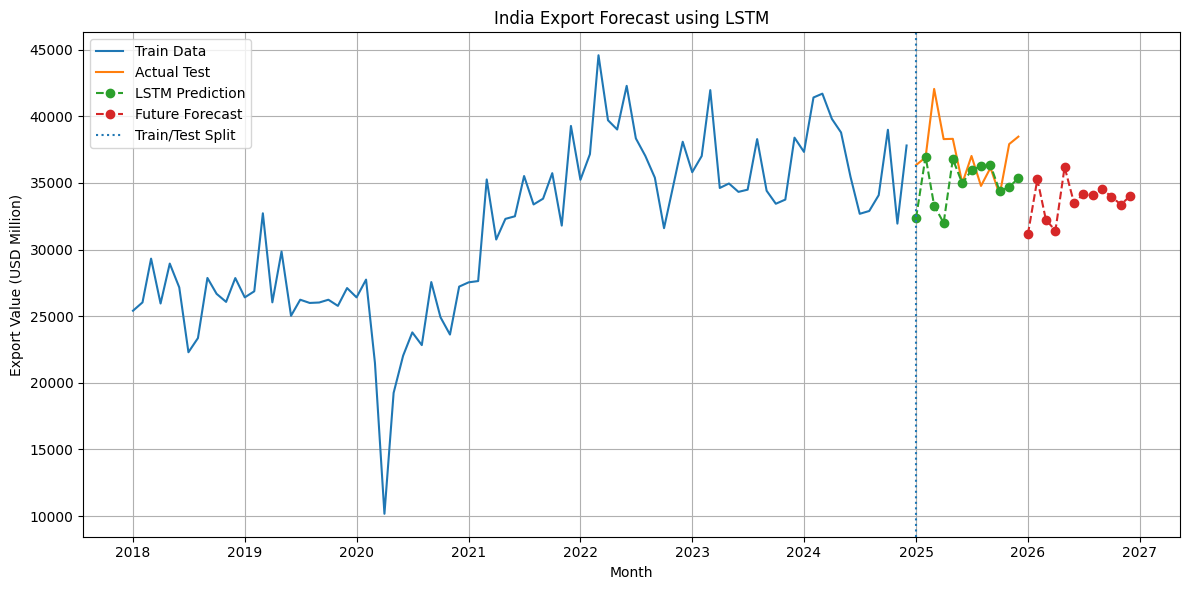

In [29]:
import matplotlib.pyplot as plt

# Historical export series
history_export = monthly['Export_Value']

train_period_index = monthly.index[:len(history_export)-N_TEST]
test_period_index  = monthly.index[len(history_export)-N_TEST:]

# Convert predictions to Series
pred_series = pd.Series(y_pred, index=test_period_index)
future_series = pd.Series(future_preds, index=future_index)

# Plot
plt.figure(figsize=(12,6))

# Convert PeriodIndex to TimestampIndex for plotting
plt.plot(train_period_index.to_timestamp(),
         history_export.loc[train_period_index],
         label="Train Data")

plt.plot(test_period_index.to_timestamp(),
         history_export.loc[test_period_index],
         label="Actual Test")

plt.plot(pred_series.index.to_timestamp(),
         pred_series,
         linestyle='--',
         marker='o',
         label="LSTM Prediction")

plt.plot(future_series.index.to_timestamp(),
         future_series,
         linestyle='--',
         marker='o',
         label="Future Forecast")

plt.axvline(test_period_index.to_timestamp()[0], linestyle=":", label="Train/Test Split")
plt.title("India Export Forecast using LSTM")
plt.xlabel("Month")
plt.ylabel("Export Value (USD Million)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()